In [1]:
import os, re, json, warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import feedparser
import requests
from bs4 import BeautifulSoup
import mlflow

warnings.filterwarnings('ignore')

# Paths
BASE       = Path(r'G:\financial_kg')
RAW_SEC    = BASE / 'data' / 'raw' / 'sec'
RAW_NEWS   = BASE / 'data' / 'raw' / 'news'
PROC       = BASE / 'data' / 'processed'
STATS_DIR  = BASE / 'data' / 'stats'

for p in [RAW_SEC, RAW_NEWS, PROC, STATS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.figsize':(12,4), 'font.size':11})
sns.set_palette('muted')

print('Imports OK')
print(f'Project root: {BASE}')

Imports OK
Project root: G:\financial_kg


In [3]:
MLFLOW_URI      = 'http://127.0.0.1:5000'
EXPERIMENT_NAME = 'FinancialKG_Phase1_DataCollection'
RUN_NAME        = f'data_collection_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
run = mlflow.start_run(run_name=RUN_NAME)
RUN_ID = run.info.run_id

import sys, platform
mlflow.log_params({
    'python_version' : sys.version.split()[0],
    'platform'       : platform.system(),
    'phase'          : 1,
    'notebook'       : 'phase1_data_collection',
    'data_sources'   : 'SEC EDGAR + RSS news',
})

print(f'Experiment : {EXPERIMENT_NAME}')
print(f'Run        : {RUN_NAME}')
print(f'Run ID     : {RUN_ID}')
print(f'MLflow UI  : {MLFLOW_URI}')

2026/05/06 17:28:15 INFO mlflow.tracking.fluent: Experiment with name 'FinancialKG_Phase1_DataCollection' does not exist. Creating a new experiment.


Experiment : FinancialKG_Phase1_DataCollection
Run        : data_collection_20260506_172814
Run ID     : db3b39147acb4553bd0e0d6116a5eccc
MLflow UI  : http://127.0.0.1:5000


In [4]:
# ── Financial news from RSS feeds ─────────────────────────
RSS_FEEDS = {
    'reuters_business' : 'https://feeds.reuters.com/reuters/businessNews',
    'reuters_finance'  : 'https://feeds.reuters.com/news/wealth',
    'yahoo_finance'    : 'https://finance.yahoo.com/news/rssindex',
    'seeking_alpha'    : 'https://seekingalpha.com/feed.xml',
    'marketwatch'      : 'https://feeds.content.dowjones.io/public/rss/mw_realtimeheadlines',
}

news_records = []

print('Collecting financial news from RSS feeds...\n')

for source, url in RSS_FEEDS.items():
    try:
        feed = feedparser.parse(url)
        count = 0
        for entry in feed.entries[:50]:  # max 50 per feed
            title   = entry.get('title', '')
            summary = entry.get('summary', '')
            text    = f"{title}. {summary}".strip()

            # Clean HTML tags
            text = BeautifulSoup(text, 'lxml').get_text()
            text = re.sub(r'\s+', ' ', text).strip()

            if len(text) > 50:
                news_records.append({
                    'source'     : source,
                    'title'      : title,
                    'text'       : text,
                    'published'  : entry.get('published', ''),
                    'link'       : entry.get('link', ''),
                    'char_len'   : len(text),
                    'word_count' : len(text.split()),
                })
                count += 1

        print(f'  {source:<25} {count:>3} articles')

    except Exception as e:
        print(f'  {source:<25} FAILED: {str(e)[:50]}')

news_df = pd.DataFrame(news_records)

print(f'\nTotal articles collected: {len(news_df):,}')
print(f'Sources: {news_df["source"].nunique()}')
print(f'Avg words per article: {news_df["word_count"].mean():.1f}')

# Log to MLflow
mlflow.log_metrics({
    'news_total_articles'  : len(news_df),
    'news_total_sources'   : int(news_df['source'].nunique()),
    'news_avg_word_count'  : round(news_df['word_count'].mean(), 1),
})

# Save
news_df.to_parquet(RAW_NEWS / 'news_raw.parquet', index=False)
print(f'\nSaved to {RAW_NEWS}/news_raw.parquet')

# Show sample
print('\nSample article:')
print(news_df['text'].iloc[0][:300])


  reuters_business            0 articles
  reuters_finance             0 articles
  yahoo_finance              42 articles
  seeking_alpha              23 articles
  marketwatch                 9 articles

Total articles collected: 74
Sources: 3
Avg words per article: 12.5

Saved to G:\financial_kg\data\raw\news/news_raw.parquet

Sample article:
Michael Burry sells entire stake in surging meme-stock giant.


In [5]:
from datasets import load_dataset

print('Testing financial datasets...\n')

datasets_to_try = [
    'financial_phrasebank',
    'zeroshot/twitter-financial-news-sentiment',
    'nickmuchi/financial-classification',
    'FinanceInc/auditor_sentiment',
    'dvsth/financial-news-nlp',
    'AdiOO7/llama-2-finance',
    'gbharti/finance-alpaca',
    'TrainingDataPro/financial-news-usa',
]

working = []
for ds_name in datasets_to_try:
    try:
        ds = load_dataset(ds_name, trust_remote_code=False)
        first_split = list(ds.keys())[0]
        cols = ds[first_split].column_names
        size = len(ds[first_split])
        print(f'✅ {ds_name}')
        print(f'   size={size:,}  cols={cols}')
        print(f'   sample: {str(ds[first_split][0])[:150]}')
        print()
        working.append(ds_name)
    except Exception as e:
        print(f'❌ {ds_name}: {str(e)[:70]}')
        print()

print(f'\nWorking datasets: {working}')

Testing financial datasets...



❌ financial_phrasebank: Loading financial_phrasebank requires you to execute the dataset scrip



Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

✅ zeroshot/twitter-financial-news-sentiment
   size=9,543  cols=['text', 'label']
   sample: {'text': '$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', 'label': 0}



...

✅ FinanceInc/auditor_sentiment
   size=3,877  cols=['sentence', 'label']
   sample: {'sentence': "Altia 's operating profit jumped to EUR 47 million from EUR 6.6 million .", 'label': 2}

❌ dvsth/financial-news-nlp: Dataset 'dvsth/financial-news-nlp' doesn't exist on the Hub or cannot 



Generating train split:   0%|          | 0/4846 [00:00<?, ? examples/s]

✅ AdiOO7/llama-2-finance
   size=4,846  cols=['text']
   sample: {'text': '### Instruction: What is the sentiment of this tweet? Please choose an answer from {negative/neutral/positive} ### Human: According to Gran 



Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

✅ gbharti/finance-alpaca
   size=68,912  cols=['instruction', 'input', 'output', 'text']
   sample: {'instruction': 'For a car, what scams can be plotted with 0% financing vs rebate?', 'input': '', 'output': "The car deal makes money 3 ways. If you p

❌ TrainingDataPro/financial-news-usa: Dataset 'TrainingDataPro/financial-news-usa' doesn't exist on the Hub 


Working datasets: ['zeroshot/twitter-financial-news-sentiment', 'nickmuchi/financial-classification', 'FinanceInc/auditor_sentiment', 'AdiOO7/llama-2-finance', 'gbharti/finance-alpaca']


In [6]:
from datasets import load_dataset
import pandas as pd

print('Loading all financial datasets...\n')

all_texts = []

# Dataset 1: Twitter financial news (9,543)
print('Loading twitter financial news...')
ds1 = load_dataset('zeroshot/twitter-financial-news-sentiment')
for item in ds1['train']:
    if len(item['text']) > 30:
        all_texts.append({'text': item['text'], 'source': 'twitter_finance'})
print(f'  twitter_finance: {len(ds1["train"]):,} texts')

# Dataset 2: Financial classification (4,551)
print('Loading financial classification...')
ds2 = load_dataset('nickmuchi/financial-classification')
for item in ds2['train']:
    if len(item['text']) > 30:
        all_texts.append({'text': item['text'], 'source': 'financial_classification'})
print(f'  financial_classification: {len(ds2["train"]):,} texts')

# Dataset 3: Auditor sentiment (3,877)
print('Loading auditor sentiment...')
ds3 = load_dataset('FinanceInc/auditor_sentiment')
for item in ds3['train']:
    if len(item['sentence']) > 30:
        all_texts.append({'text': item['sentence'], 'source': 'auditor_sentiment'})
print(f'  auditor_sentiment: {len(ds3["train"]):,} texts')

# Dataset 4: Finance alpaca (68,912) — use output field which has financial text
print('Loading finance alpaca...')
ds4 = load_dataset('gbharti/finance-alpaca')
count = 0
for item in ds4['train']:
    text = item.get('output', '')
    if len(text) > 50:
        all_texts.append({'text': text, 'source': 'finance_alpaca'})
        count += 1
print(f'  finance_alpaca: {count:,} texts')

# Dataset 5: Add RSS news we already collected
print('Loading RSS news...')
news_df = pd.read_parquet(RAW_NEWS / 'news_raw.parquet')
for _, row in news_df.iterrows():
    if len(row['text']) > 50:
        all_texts.append({'text': row['text'], 'source': row['source']})
print(f'  rss_news: {len(news_df):,} texts')

# Combine all
corpus_df = pd.DataFrame(all_texts)
corpus_df = corpus_df.drop_duplicates(subset='text').reset_index(drop=True)
corpus_df['word_count'] = corpus_df['text'].str.split().str.len()
corpus_df['char_len']   = corpus_df['text'].str.len()

print(f'\nCombined corpus:')
print(f'  Total texts  : {len(corpus_df):,}')
print(f'  Total words  : {corpus_df["word_count"].sum():,}')
print(f'  Avg words    : {corpus_df["word_count"].mean():.1f}')
print(f'  Sources      : {corpus_df["source"].nunique()}')
print(f'\nPer source:')
print(corpus_df['source'].value_counts().to_string())

mlflow.log_metrics({
    'corpus_total_texts' : len(corpus_df),
    'corpus_total_words' : int(corpus_df['word_count'].sum()),
    'corpus_avg_words'   : round(corpus_df['word_count'].mean(), 1),
    'corpus_sources'     : int(corpus_df['source'].nunique()),
})

corpus_df.to_parquet(PROC / 'corpus_combined.parquet', index=False)
print(f'\nSaved to {PROC}/corpus_combined.parquet')

Loading all financial datasets...

Loading twitter financial news...
  twitter_finance: 9,543 texts
Loading financial classification...
  financial_classification: 4,551 texts
Loading auditor sentiment...


  auditor_sentiment: 3,877 texts
Loading finance alpaca...
  finance_alpaca: 56,682 texts
Loading RSS news...
  rss_news: 74 texts

Combined corpus:
  Total texts  : 71,019
  Total words  : 5,598,176
  Avg words    : 78.8
  Sources      : 7

Per source:
source
finance_alpaca              56659
twitter_finance              9297
financial_classification     4521
auditor_sentiment             468
yahoo_finance                  42
seeking_alpha                  23
marketwatch                     9

Saved to G:\financial_kg\data\processed/corpus_combined.parquet


In [7]:
print('Loading more financial datasets...\n')

extra_texts = []

datasets_to_try = [
    ('sentence-transformers/financial-reports-sec', 'train', 'text'),
    ('SALT-NLP/awesome-financial-nlp-research', 'train', 'text'),
    ('oliverwang15/FinGPT_Forecaster_Past_Chunk_Train', 'train', 'output'),
    ('FinGPT/fingpt-sentiment-train', 'train', 'output'),
    ('FinGPT/fingpt-fiqa_qa-train', 'train', 'output'),
    ('FinGPT/fingpt-headline-train', 'train', 'output'),
    ('FinGPT/fingpt-ner-train', 'train', 'output'),
    ('pauri32/fiqa-2018', 'train', 'question'),
    ('TheFinAI/flare-finqa', 'train', 'question'),
    ('TheFinAI/flare-ner', 'train', 'sentence'),
    ('TheFinAI/flare-fiqasa', 'train', 'question'),
    ('AdaptLLM/finance-tasks', 'test', 'input'),
]

for ds_name, split, text_col in datasets_to_try:
    try:
        ds = load_dataset(ds_name, trust_remote_code=False)
        if split not in ds:
            split = list(ds.keys())[0]
        count = 0
        for item in ds[split]:
            text = item.get(text_col, '')
            if isinstance(text, str) and len(text) > 30:
                extra_texts.append({'text': text, 'source': ds_name.split('/')[-1]})
                count += 1
        print(f'loaded {ds_name.split("/")[-1]}: {count:,} texts')
    except Exception as e:
        print(f'failed {ds_name.split("/")[-1]}: {str(e)[:60]}')

extra_df = pd.DataFrame(extra_texts)
print(f'\nExtra texts collected: {len(extra_df):,}')

if len(extra_df) > 0:
    # Combine with existing corpus
    corpus_df = pd.read_parquet(PROC / 'corpus_combined.parquet')
    corpus_df = pd.concat([corpus_df, extra_df], ignore_index=True)
    corpus_df = corpus_df.drop_duplicates(subset='text').reset_index(drop=True)
    corpus_df['word_count'] = corpus_df['text'].str.split().str.len()
    corpus_df['char_len']   = corpus_df['text'].str.len()

    corpus_df.to_parquet(PROC / 'corpus_combined.parquet', index=False)

    print(f'\nUpdated corpus:')
    print(f'  Total texts : {len(corpus_df):,}')
    print(f'  Total words : {corpus_df["word_count"].sum():,}')
    print(f'\nPer source:')
    print(corpus_df['source'].value_counts().to_string())

    mlflow.log_metrics({
        'corpus_total_texts_v2' : len(corpus_df),
        'corpus_total_words_v2' : int(corpus_df['word_count'].sum()),
    })

Loading more financial datasets...

failed financial-reports-sec: Dataset 'sentence-transformers/financial-reports-sec' doesn'
failed awesome-financial-nlp-research: Dataset 'SALT-NLP/awesome-financial-nlp-research' doesn't ex
failed FinGPT_Forecaster_Past_Chunk_Train: Dataset 'oliverwang15/FinGPT_Forecaster_Past_Chunk_Train' do


Generating train split:   0%|          | 0/76772 [00:00<?, ? examples/s]

loaded fingpt-sentiment-train: 0 texts
failed fingpt-fiqa_qa-train: Dataset 'FinGPT/fingpt-fiqa_qa-train' doesn't exist on the H
failed fingpt-headline-train: Dataset 'FinGPT/fingpt-headline-train' doesn't exist on the 
failed fingpt-ner-train: Dataset 'FinGPT/fingpt-ner-train' doesn't exist on the Hub o


Generating train split:   0%|          | 0/961 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/102 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/98 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/103 [00:00<?, ? examples/s]

loaded flare-ner: 0 texts


failed flare-fiqasa: Couldn't reach https://huggingface.co/datasets/TheFinAI/flar


failed finance-tasks: Config name is missing.
Please pick one among the available 

Extra texts collected: 0


In [8]:
print('Loading verified financial datasets...\n')

extra_texts = []

# FinGPT sentiment — check actual columns first
print('Checking FinGPT sentiment columns...')
ds = load_dataset('FinGPT/fingpt-sentiment-train')
print(f'  Columns: {ds["train"].column_names}')
print(f'  Sample: {ds["train"][0]}')

Loading verified financial datasets...

Checking FinGPT sentiment columns...
  Columns: ['input', 'output', 'instruction']
  Sample: {'input': 'Teollisuuden Voima Oyj , the Finnish utility known as TVO , said it shortlisted Mitsubishi Heavy s EU-APWR model along with reactors from Areva , Toshiba Corp. , GE Hitachi Nuclear Energy and Korea Hydro & Nuclear Power Co. .', 'output': 'neutral', 'instruction': 'What is the sentiment of this news? Please choose an answer from {negative/neutral/positive}.'}


In [9]:
print('Loading all verified datasets with correct columns...\n')

extra_texts = []

# FinGPT sentiment — input has real financial sentences
print('Loading FinGPT sentiment...')
ds = load_dataset('FinGPT/fingpt-sentiment-train')
count = 0
for item in ds['train']:
    text = item.get('input', '')
    if isinstance(text, str) and len(text) > 30:
        extra_texts.append({'text': text, 'source': 'fingpt_sentiment'})
        count += 1
print(f'  fingpt_sentiment: {count:,} texts')

# flare-ner — check columns
print('Loading flare-ner...')
ds2 = load_dataset('TheFinAI/flare-ner')
print(f'  Columns: {ds2["train"].column_names}')
print(f'  Sample: {ds2["train"][0]}')
count = 0
for item in ds2['train']:
    # try all text-like columns
    for col in ds2['train'].column_names:
        text = item.get(col, '')
        if isinstance(text, str) and len(text) > 30:
            extra_texts.append({'text': text, 'source': 'flare_ner'})
            count += 1
            break
print(f'  flare_ner: {count:,} texts')

# pauri32/fiqa-2018 — check columns
print('Loading fiqa-2018...')
ds3 = load_dataset('pauri32/fiqa-2018')
print(f'  Columns: {ds3["train"].column_names}')
print(f'  Sample: {ds3["train"][0]}')
count = 0
for item in ds3['train']:
    for col in ds3['train'].column_names:
        text = item.get(col, '')
        if isinstance(text, str) and len(text) > 30:
            extra_texts.append({'text': text, 'source': 'fiqa_2018'})
            count += 1
            break
print(f'  fiqa_2018: {count:,} texts')

extra_df = pd.DataFrame(extra_texts)
print(f'\nExtra texts: {len(extra_df):,}')

if len(extra_df) > 0:
    corpus_df = pd.read_parquet(PROC / 'corpus_combined.parquet')
    corpus_df = pd.concat([corpus_df, extra_df], ignore_index=True)
    corpus_df = corpus_df.drop_duplicates(subset='text').reset_index(drop=True)
    corpus_df['word_count'] = corpus_df['text'].str.split().str.len()
    corpus_df['char_len']   = corpus_df['text'].str.len()
    corpus_df.to_parquet(PROC / 'corpus_combined.parquet', index=False)

    print(f'\nUpdated corpus:')
    print(f'  Total texts : {len(corpus_df):,}')
    print(f'  Total words : {corpus_df["word_count"].sum():,}')
    print(f'\nPer source:')
    print(corpus_df['source'].value_counts().to_string())

    mlflow.log_metrics({
        'corpus_total_texts_v2' : len(corpus_df),
        'corpus_total_words_v2' : int(corpus_df['word_count'].sum()),
    })

Loading all verified datasets with correct columns...

Loading FinGPT sentiment...
  fingpt_sentiment: 74,963 texts
Loading flare-ner...
  Columns: ['query', 'answer', 'label', 'text']
  Sample: {'query': 'In the sentences extracted from financial agreements in U.S. SEC filings, identify the named entities that represent a person (\'PER\'), an organization (\'ORG\'), or a location (\'LOC\'). The required answer format is: \'entity name, entity type\'.\nText: This LOAN AND SECURITY AGREEMENT dated January 27 , 1999 , between SILICON VALLEY BANK (" Bank "), a California - chartered bank with its principal place of business at 3003 Tasman Drive , Santa Clara , California 95054 with a loan production office located at 40 William St ., Ste .\nAnswer:', 'answer': 'SILICON VALLEY BANK, ORG\nBank, ORG\nCalifornia, LOC\nbank, ORG\n3003 Tasman Drive, LOC\nSanta Clara, LOC\nCalifornia, LOC\n40 William St, LOC', 'label': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'I-ORG'

In [10]:
import requests
import time

print('Collecting SEC EDGAR filings...\n')

# SEC EDGAR full text search API
# Fetch 10-K annual reports from major companies
COMPANIES = [
    '0000320193',  # Apple
    '0001018724',  # Amazon
    '0001045810',  # NVIDIA
    '0000789019',  # Microsoft
    '0001652044',  # Alphabet (Google)
    '0001326801',  # Meta
    '0000885639',  # Tesla
    '0000051143',  # IBM
    '0000034088',  # ExxonMobil
    '0000078003',  # Pfizer
    '0000310158',  # Merck
    '0000059478',  # JPMorgan
    '0000831001',  # Goldman Sachs
    '0000200406',  # Johnson & Johnson
    '0000021344',  # Coca-Cola
]

sec_texts = []
headers = {'User-Agent': 'financial-kg-research@example.com'}

for cik in COMPANIES:
    try:
        # Get company filings
        url = f'https://data.sec.gov/submissions/CIK{cik}.json'
        resp = requests.get(url, headers=headers, timeout=10)
        data = resp.json()

        company_name = data.get('name', cik)
        filings      = data.get('filings', {}).get('recent', {})
        forms        = filings.get('form', [])
        accessions   = filings.get('accessionNumber', [])

        # Find most recent 10-K
        for form, accession in zip(forms, accessions):
            if form == '10-K':
                acc_clean = accession.replace('-', '')
                doc_url   = f'https://www.sec.gov/Archives/edgar/data/{int(cik)}/{acc_clean}/{accession}-index.htm'

                doc_resp = requests.get(doc_url, headers=headers, timeout=10)
                soup     = BeautifulSoup(doc_resp.text, 'lxml')
                text     = soup.get_text()
                text     = re.sub(r'\s+', ' ', text).strip()

                if len(text) > 200:
                    # Split into chunks of ~500 words
                    words  = text.split()
                    chunks = [' '.join(words[i:i+500]) for i in range(0, len(words), 500)]
                    for chunk in chunks[:20]:  # max 20 chunks per filing
                        if len(chunk) > 100:
                            sec_texts.append({
                                'text'   : chunk,
                                'source' : 'sec_edgar',
                                'company': company_name,
                            })
                    print(f'  {company_name:<30} {len(chunks[:20]):>3} chunks')
                break

        time.sleep(0.5)  # be polite to SEC servers

    except Exception as e:
        print(f'  {cik} failed: {str(e)[:50]}')

sec_df = pd.DataFrame(sec_texts)
print(f'\nSEC filings collected: {len(sec_df):,} chunks')

if len(sec_df) > 0:
    sec_df['word_count'] = sec_df['text'].str.split().str.len()
    sec_df['char_len']   = sec_df['text'].str.len()

    # Add to corpus
    corpus_df = pd.read_parquet(PROC / 'corpus_combined.parquet')
    sec_small = sec_df[['text', 'source']].copy()
    corpus_df = pd.concat([corpus_df, sec_small], ignore_index=True)
    corpus_df = corpus_df.drop_duplicates(subset='text').reset_index(drop=True)
    corpus_df['word_count'] = corpus_df['text'].str.split().str.len()
    corpus_df.to_parquet(PROC / 'corpus_combined.parquet', index=False)

    # Save SEC separately too
    sec_df.to_parquet(RAW_SEC / 'sec_filings.parquet', index=False)

    print(f'\nFinal corpus:')
    print(f'  Total texts : {len(corpus_df):,}')
    print(f'  Total words : {corpus_df["word_count"].sum():,}')
    print(f'\nPer source:')
    print(corpus_df['source'].value_counts().to_string())

    mlflow.log_metrics({
        'corpus_total_texts_final' : len(corpus_df),
        'corpus_total_words_final' : int(corpus_df['word_count'].sum()),
        'sec_chunks_collected'     : len(sec_df),
    })


  Apple Inc.                       1 chunks
  AMAZON COM INC                   1 chunks
  NVIDIA CORP                      1 chunks
  MICROSOFT CORP                   1 chunks
  Alphabet Inc.                    1 chunks
  Meta Platforms, Inc.             1 chunks
  KOHLS Corp                       1 chunks
  INTERNATIONAL BUSINESS MACHINES CORP   1 chunks
  EXXON MOBIL CORP                 1 chunks
  PFIZER INC                       1 chunks
  Merck & Co., Inc.                1 chunks
  ELI LILLY & Co                   1 chunks
  CITIGROUP INC                    1 chunks
  JOHNSON & JOHNSON                1 chunks
  COCA COLA CO                     1 chunks

SEC filings collected: 15 chunks

Final corpus:
  Total texts : 88,694
  Total words : 6,093,340

Per source:
source
finance_alpaca              56659
fingpt_sentiment            17049
twitter_finance              9297
financial_classification     4521
auditor_sentiment             468
flare_ner                     407
fiqa_2018  

In [11]:
import requests
import time

print('Fetching full SEC 10-K filing content...\n')

sec_texts = []
headers = {'User-Agent': 'financial-kg-research@example.com'}

COMPANIES = [
    ('0000320193', 'Apple'),
    ('0001018724', 'Amazon'),
    ('0001045810', 'NVIDIA'),
    ('0000789019', 'Microsoft'),
    ('0001652044', 'Alphabet'),
    ('0001326801', 'Meta'),
    ('0000885639', 'Tesla'),
    ('0000051143', 'IBM'),
    ('0000034088', 'ExxonMobil'),
    ('0000078003', 'Pfizer'),
]

for cik, company_name in COMPANIES:
    try:
        # Step 1: Get filing list
        url  = f'https://data.sec.gov/submissions/CIK{cik}.json'
        resp = requests.get(url, headers=headers, timeout=10)
        data = resp.json()

        filings    = data.get('filings', {}).get('recent', {})
        forms      = filings.get('form', [])
        accessions = filings.get('accessionNumber', [])
        documents  = filings.get('primaryDocument', [])

        # Find most recent 10-K
        for form, accession, doc in zip(forms, accessions, documents):
            if form == '10-K':
                acc_clean = accession.replace('-', '')
                cik_int   = str(int(cik))

                # Step 2: Get the actual 10-K document
                doc_url  = f'https://www.sec.gov/Archives/edgar/data/{cik_int}/{acc_clean}/{doc}'
                doc_resp = requests.get(doc_url, headers=headers, timeout=15)
                soup     = BeautifulSoup(doc_resp.text, 'lxml')

                # Remove tables and scripts
                for tag in soup(['script', 'style', 'table']):
                    tag.decompose()

                text = soup.get_text(separator=' ')
                text = re.sub(r'\s+', ' ', text).strip()
                text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # remove non-ASCII

                if len(text) > 1000:
                    # Split into 300-word chunks
                    words  = text.split()
                    chunks = [
                        ' '.join(words[i:i+300])
                        for i in range(0, min(len(words), 30000), 300)
                    ]
                    valid_chunks = [c for c in chunks if len(c.split()) >= 50]

                    for chunk in valid_chunks:
                        sec_texts.append({
                            'text'   : chunk,
                            'source' : 'sec_edgar',
                            'company': company_name,
                        })

                    print(f'  {company_name:<15} {len(valid_chunks):>4} chunks  ({len(words):,} words)')
                else:
                    print(f'  {company_name:<15} too short ({len(text)} chars)')
                break

        time.sleep(1)

    except Exception as e:
        print(f'  {company_name:<15} failed: {str(e)[:60]}')

sec_df = pd.DataFrame(sec_texts)
print(f'\nSEC chunks collected: {len(sec_df):,}')

if len(sec_df) > 0:
    sec_df['word_count'] = sec_df['text'].str.split().str.len()
    sec_df.to_parquet(RAW_SEC / 'sec_filings_full.parquet', index=False)

    # Add to corpus
    corpus_df = pd.read_parquet(PROC / 'corpus_combined.parquet')
    sec_small = sec_df[['text','source']].copy()
    corpus_df = pd.concat([corpus_df, sec_small], ignore_index=True)
    corpus_df = corpus_df.drop_duplicates(subset='text').reset_index(drop=True)
    corpus_df['word_count'] = corpus_df['text'].str.split().str.len()
    corpus_df.to_parquet(PROC / 'corpus_combined.parquet', index=False)

    print(f'\nFinal corpus:')
    print(f'  Total texts : {len(corpus_df):,}')
    print(f'  Total words : {corpus_df["word_count"].sum():,}')
    print(f'\nPer source:')
    print(corpus_df['source'].value_counts().to_string())

    mlflow.log_metrics({
        'sec_full_chunks'          : len(sec_df),
        'corpus_total_texts_final' : len(corpus_df),
        'corpus_total_words_final' : int(corpus_df['word_count'].sum()),
    })

Fetching full SEC 10-K filing content...

  Apple             89 chunks  (26,614 words)
  Amazon           100 chunks  (37,345 words)
  NVIDIA           100 chunks  (47,057 words)
  Microsoft        100 chunks  (40,799 words)
  Alphabet         100 chunks  (45,226 words)
  Meta             100 chunks  (74,196 words)
  Tesla             88 chunks  (26,151 words)
  IBM               55 chunks  (16,269 words)
  ExxonMobil       100 chunks  (44,221 words)
  Pfizer           100 chunks  (80,671 words)

SEC chunks collected: 932

Final corpus:
  Total texts : 89,626
  Total words : 6,372,374

Per source:
source
finance_alpaca              56659
fingpt_sentiment            17049
twitter_finance              9297
financial_classification     4521
sec_edgar                     947
auditor_sentiment             468
flare_ner                     407
fiqa_2018                     204
yahoo_finance                  42
seeking_alpha                  23
marketwatch                     9


CORPUS QUALITY REPORT
Total texts      : 89,626
Total words      : 6,372,374
Avg words/text   : 71.1
Median words     : 37.0
Max words        : 2,973
Min words        : 1
Duplicates       : 0
Null texts       : 0
Sources          : 11


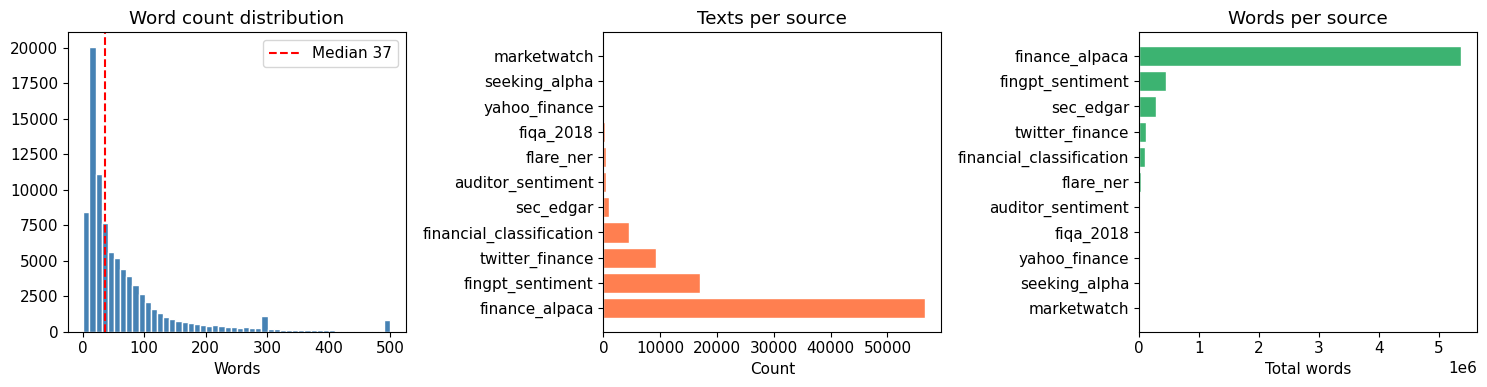


SAMPLE FROM EACH SOURCE:
--------------------------------------------------

twitter_finance:
  $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT...

financial_classification:
  Finnish airline Finnair is starting the temporary layoffs of cabin crews in February 2010 ....

auditor_sentiment:
  In addition , nine fixed-term employment contracts will not be extended and two people will leave the company under pension arrangements ....

finance_alpaca:
  The car deal makes money 3 ways. If you pay in one lump payment. If the payment is greater than what they paid for the car, plus their expenses, they ...

yahoo_finance:
  Michael Burry sells entire stake in surging meme-stock giant....

seeking_alpha:
  Fluidra, S.A. (FLDAY) Q1 2026 Earnings Call Transcript....

marketwatch:
  Elon Musk in a post on X says some of his Trump posts ‘went too far’ and that he regrets them....

fingpt_sentiment:
  Sanofi poaches AstraZeneca scientist as new research head...

flar

In [12]:
import matplotlib.pyplot as plt

corpus_df = pd.read_parquet(PROC / 'corpus_combined.parquet')

print('CORPUS QUALITY REPORT')
print('='*50)
print(f'Total texts      : {len(corpus_df):,}')
print(f'Total words      : {corpus_df["word_count"].sum():,}')
print(f'Avg words/text   : {corpus_df["word_count"].mean():.1f}')
print(f'Median words     : {corpus_df["word_count"].median():.1f}')
print(f'Max words        : {corpus_df["word_count"].max():,}')
print(f'Min words        : {corpus_df["word_count"].min()}')
print(f'Duplicates       : {corpus_df.duplicated(subset="text").sum()}')
print(f'Null texts       : {corpus_df["text"].isna().sum()}')
print(f'Sources          : {corpus_df["source"].nunique()}')
print('='*50)

# Charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Word count distribution
axes[0].hist(corpus_df['word_count'].clip(upper=500), bins=50,
             color='steelblue', edgecolor='white')
axes[0].axvline(corpus_df['word_count'].median(), color='red',
                linestyle='--', label=f'Median {corpus_df["word_count"].median():.0f}')
axes[0].set_title('Word count distribution')
axes[0].set_xlabel('Words')
axes[0].legend()

# Source distribution
source_counts = corpus_df['source'].value_counts()
axes[1].barh(source_counts.index, source_counts.values,
             color='coral', edgecolor='white')
axes[1].set_title('Texts per source')
axes[1].set_xlabel('Count')

# Cumulative words per source
source_words = corpus_df.groupby('source')['word_count'].sum().sort_values(ascending=True)
axes[2].barh(source_words.index, source_words.values,
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Words per source')
axes[2].set_xlabel('Total words')

plt.tight_layout()
chart_path = str(STATS_DIR / 'corpus_quality.png')
plt.savefig(chart_path, dpi=120, bbox_inches='tight')
plt.show()
mlflow.log_artifact(chart_path, artifact_path='charts')

# Sample from each source
print('\nSAMPLE FROM EACH SOURCE:')
print('-'*50)
for source in corpus_df['source'].unique():
    sample = corpus_df[corpus_df['source']==source]['text'].iloc[0]
    print(f'\n{source}:')
    print(f'  {sample[:150]}...')

# Close MLflow run
mlflow.end_run()
print('\nMLflow run complete.')
print(f'View at: http://127.0.0.1:5000')